In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.metrics import classification_report

In [23]:
# Dataset loading and preprocessing
train_df = pd.read_csv("Train_data.csv")
test_df = pd.read_csv("Test_data.csv")
train_labels = train_df['class'] #Extracts the label column

#Combines the training features and test data and Drops the 'class' column from training data
#To ensure consistent label encoding for all data.
combined_df = pd.concat([train_df.drop(columns=['class']), test_df], axis=0)
#Encoding categorical features
cat_cols = ['protocol_type', 'service', 'flag']
for col in cat_cols:
    le = LabelEncoder()
    combined_df[col] = le.fit_transform(combined_df[col])

#Splitting back the data
train_X = combined_df.iloc[:len(train_df)] #original training features
test_X = combined_df.iloc[len(train_df):] #original test features
label_encoder = LabelEncoder()
train_y = label_encoder.fit_transform(train_labels) #Converts the 'class' labels into numbers

In [ ]:
#Split Training Data.
from sklearn.model_selection import train_test_split
# Split the training dataset (80% for training, 20% for validation)
X_train, X_val, y_train, y_val = train_test_split(train_X, train_y, test_size=0.2, random_state=42)
# Train Random Forest on 80%
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)
# Predict on 20% validation data
val_preds = clf.predict(X_val)
# Evaluate performance
#from sklearn.metrics import classification_report
#print(classification_report(y_val, val_preds))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2365
           1       1.00      1.00      1.00      2674

    accuracy                           1.00      5039
   macro avg       1.00      1.00      1.00      5039
weighted avg       1.00      1.00      1.00      5039



In [ ]:
final_clf = RandomForestClassifier(random_state=42)
final_clf.fit(train_X, train_y)

RandomForestClassifier(random_state=42)

In [ ]:
supervised_preds = final_clf.predict(test_X)
supervised_preds_label = label_encoder.inverse_transform(supervised_preds)

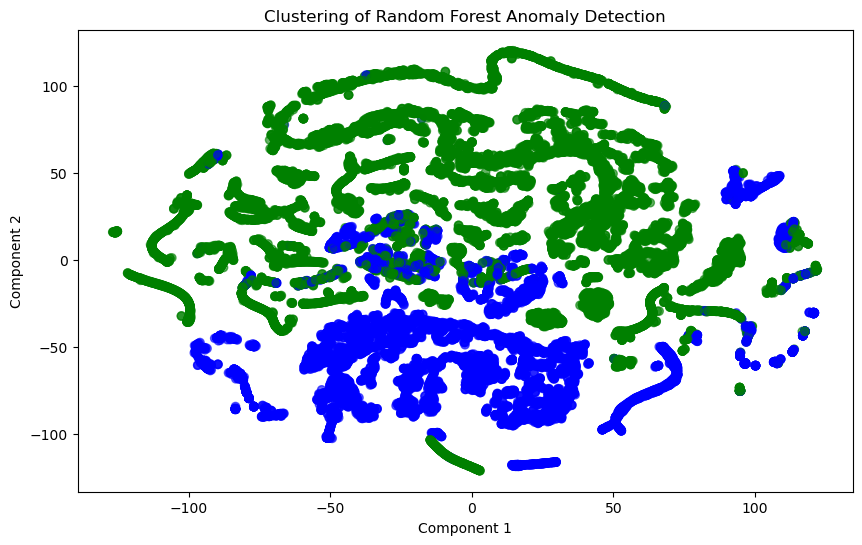

In [8]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

X_tsne = TSNE(n_components=2, random_state=42).fit_transform(test_X)
colors = ['blue' if p == 0 else 'green' for p in supervised_preds]

plt.figure(figsize=(10, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=colors, alpha=0.6)
plt.title("Clustering of Random Forest Anomaly Detection")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.show()


In [9]:
iso_model = IsolationForest(contamination=0.05, random_state=42)  # contamination = % anomalies expected
iso_model.fit(train_X)  # Only features, no labels

IsolationForest(contamination=0.05, random_state=42)

In [10]:
unsupervised_preds = iso_model.predict(test_X)  # Output: 1 = normal, -1 = anomaly
unsup_labels = ['Anomaly' if val == -1 else 'Normal' for val in unsupervised_preds]
output_df = pd.DataFrame({'Prediction': unsup_labels})
#output_df.to_csv("Unsupervised_IsolationForest_Output.csv", index=False)

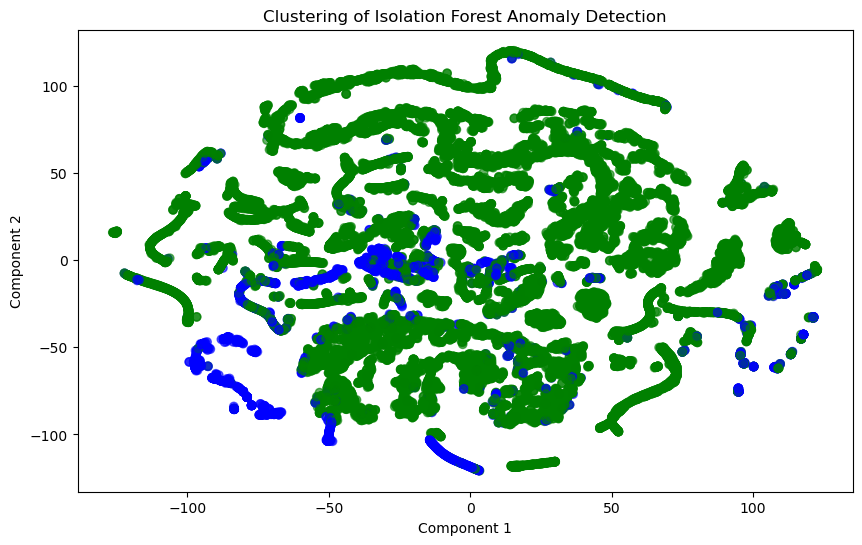

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

X_tsne = TSNE(n_components=2, random_state=42).fit_transform(test_X)
colors = ['blue' if p == -1 else 'green' for p in unsupervised_preds]

plt.figure(figsize=(10, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=colors, alpha=0.6)
plt.title("Clustering of Isolation Forest Anomaly Detection")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.show()


In [66]:

print(len(supervised_preds_label), len(unsupervised_preds))
combined_results = pd.DataFrame({
    'Supervised_Pred_Label': supervised_preds_label,
    'Unsupervised_Pred_Label': unsup_labels
})
full_output = test_df.copy()  # original test data
full_output['Supervised_Pred_Label'] = supervised_preds_label
full_output['Unsupervised_Pred_Label'] = unsup_labels

min_len = min(len(actual_labels), len(supervised_preds), len(unsupervised_preds))
actual_labels = actual_labels[:min_len]
supervised_preds = supervised_preds[:min_len]
unsupervised_preds = unsupervised_preds[:min_len]

# Combine into a DataFrame
results_df = pd.DataFrame({
    'Actual_Label': actual_labels,
    'Supervised_Prediction': supervised_preds,
    'Unsupervised_Prediction': unsupervised_preds
})

# Apply to both prediction columns
results_df['Supervised_Prediction'] = results_df['Supervised_Prediction'].apply(convert_label)
results_df['Unsupervised_Prediction'] = results_df['Unsupervised_Prediction'].apply(convert_label)
results_df.to_csv("combined_results.csv", index=False)
print("Saved to 'combined_results.csv'")




22544 22544
Saved to 'combined_results.csv'
